# YOLO Training Monitor

Paste a training run directory below (e.g. `runs/detect/train`) and run all cells to see settings, metrics, and sample images.

Re-run cells while training is in progress to refresh.

In [45]:
# --- Config ---
RUN_DIR = "runs/detect/train"  # <-- paste your run directory here

from pathlib import Path
run_dir = Path(RUN_DIR).resolve()
assert run_dir.exists(), f"Run dir not found: {run_dir}"
print(f"Monitoring: {run_dir}")

Monitoring: /home/log/Github/ML_Spring_26_Project/runs/detect/train


## Training settings (`args.yaml`)

In [46]:
import yaml

args_path = run_dir / "args.yaml"
if args_path.exists():
    with open(args_path) as f:
        args = yaml.safe_load(f)
    # Show the most relevant keys first
    key_order = ["model", "data", "epochs", "batch", "imgsz", "device", "optimizer", "lr0", "lrf", "momentum", "weight_decay", "patience", "save_dir"]
    for k in key_order:
        if k in args:
            print(f"  {k:20s} = {args[k]}")
    print("\n--- Full args ---")
    for k, v in sorted(args.items()):
        if k not in key_order:
            print(f"  {k:20s} = {v}")
else:
    print(f"No args.yaml found at {args_path}")

  model                = yolo26n.pt
  data                 = data/manual_label_4_15_26/dataset.yaml
  epochs               = 50
  batch                = 16
  imgsz                = 640
  device               = None
  optimizer            = auto
  lr0                  = 0.01
  lrf                  = 0.01
  momentum             = 0.937
  weight_decay         = 0.0005
  patience             = 100
  save_dir             = /home/log/Github/ML_Spring_26_Project/runs/detect/train

--- Full args ---
  agnostic_nms         = False
  amp                  = True
  angle                = 1.0
  augment              = False
  auto_augment         = randaugment
  bgr                  = 0.0
  box                  = 7.5
  cache                = False
  cfg                  = None
  classes              = None
  close_mosaic         = 10
  cls                  = 0.5
  cls_pw               = 0.0
  compile              = False
  conf                 = None
  copy_paste           = 0.0
  copy_paste_mode   

## Progress & metrics (`results.csv`)

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = run_dir / "results.csv"
if not results_path.exists():
    print(f"No results.csv yet at {results_path} — training may not have written any epochs.")
else:
    df = pd.read_csv(results_path)
    df.columns = [c.strip() for c in df.columns]
    total_epochs = args.get("epochs", "?") if args_path.exists() else "?"
    current_epoch = int(df["epoch"].iloc[-1]) if "epoch" in df.columns else len(df)
    print(f"Progress: epoch {current_epoch} / {total_epochs}")
    print(f"Rows in results.csv: {len(df)}")
    display(df.tail(10))

Progress: epoch 50 / 50
Rows in results.csv: 50


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
40,41,65.0879,1.86258,1.21501,0.00233,0.71339,0.64799,0.70997,0.38168,1.73863,1.00921,0.00310,0.000416,0.000416,0.000416
41,42,66.2705,1.78742,1.08902,0.00229,0.72119,0.60894,0.69366,0.37514,1.74811,1.07690,0.00309,0.000376,0.000376,0.000376
42,43,67.4466,1.85741,1.13825,0.00227,0.73564,0.58101,0.68177,0.36307,1.80560,1.06303,0.00318,0.000337,0.000337,0.000337
43,44,68.6488,1.83672,1.10802,0.00223,0.75603,0.58170,0.68678,0.37108,1.79127,1.04337,0.00314,0.000297,0.000297,0.000297
44,45,69.8309,1.75131,1.07414,0.00227,0.71921,0.61815,0.69483,0.36721,1.79432,1.05629,0.00316,0.000258,0.000258,0.000258
45,46,71.0331,1.80488,1.09593,0.00222,0.70346,0.63083,0.69341,0.35534,1.82908,1.06665,0.00322,0.000218,0.000218,0.000218
46,47,72.2281,1.76122,1.04545,0.00219,0.67245,0.65373,0.68965,0.34746,1.83349,1.06200,0.00324,0.000178,0.000178,0.000178
47,48,73.4303,1.79017,1.04942,0.00219,0.69367,0.63911,0.68909,0.35306,1.80888,1.04209,0.00318,0.000139,0.000139,0.000139
48,49,74.6209,1.75977,1.03201,0.00218,0.69625,0.63575,0.69323,0.36005,1.79414,1.02858,0.00316,0.000099,0.000099,0.000099
49,50,75.8035,1.73072,1.02237,0.00218,0.70083,0.63128,0.69634,0.36305,1.78693,1.01991,0.00314,0.000060,0.000060,0.000060


/tmp/ipykernel_468506/2674398147.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)


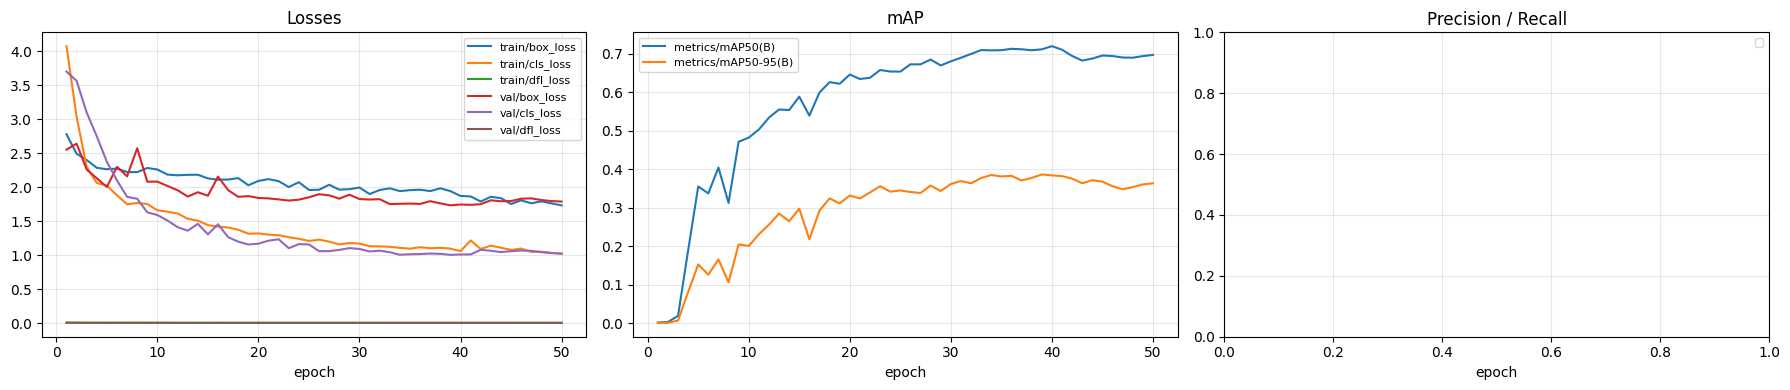

In [48]:
# Plot losses and mAP curves
if results_path.exists():
    loss_cols = [c for c in df.columns if "loss" in c.lower()]
    map_cols = [c for c in df.columns if "mAP" in c]
    pr_cols = [c for c in df.columns if c.split("/")[-1] in ("precision", "recall") or c.endswith("precision") or c.endswith("recall")]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for c in loss_cols:
        axes[0].plot(df["epoch"], df[c], label=c)
    axes[0].set_title("Losses")
    axes[0].set_xlabel("epoch")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    for c in map_cols:
        axes[1].plot(df["epoch"], df[c], label=c)
    axes[1].set_title("mAP")
    axes[1].set_xlabel("epoch")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    for c in pr_cols:
        axes[2].plot(df["epoch"], df[c], label=c)
    axes[2].set_title("Precision / Recall")
    axes[2].set_xlabel("epoch")
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Results plot (`results.png`)

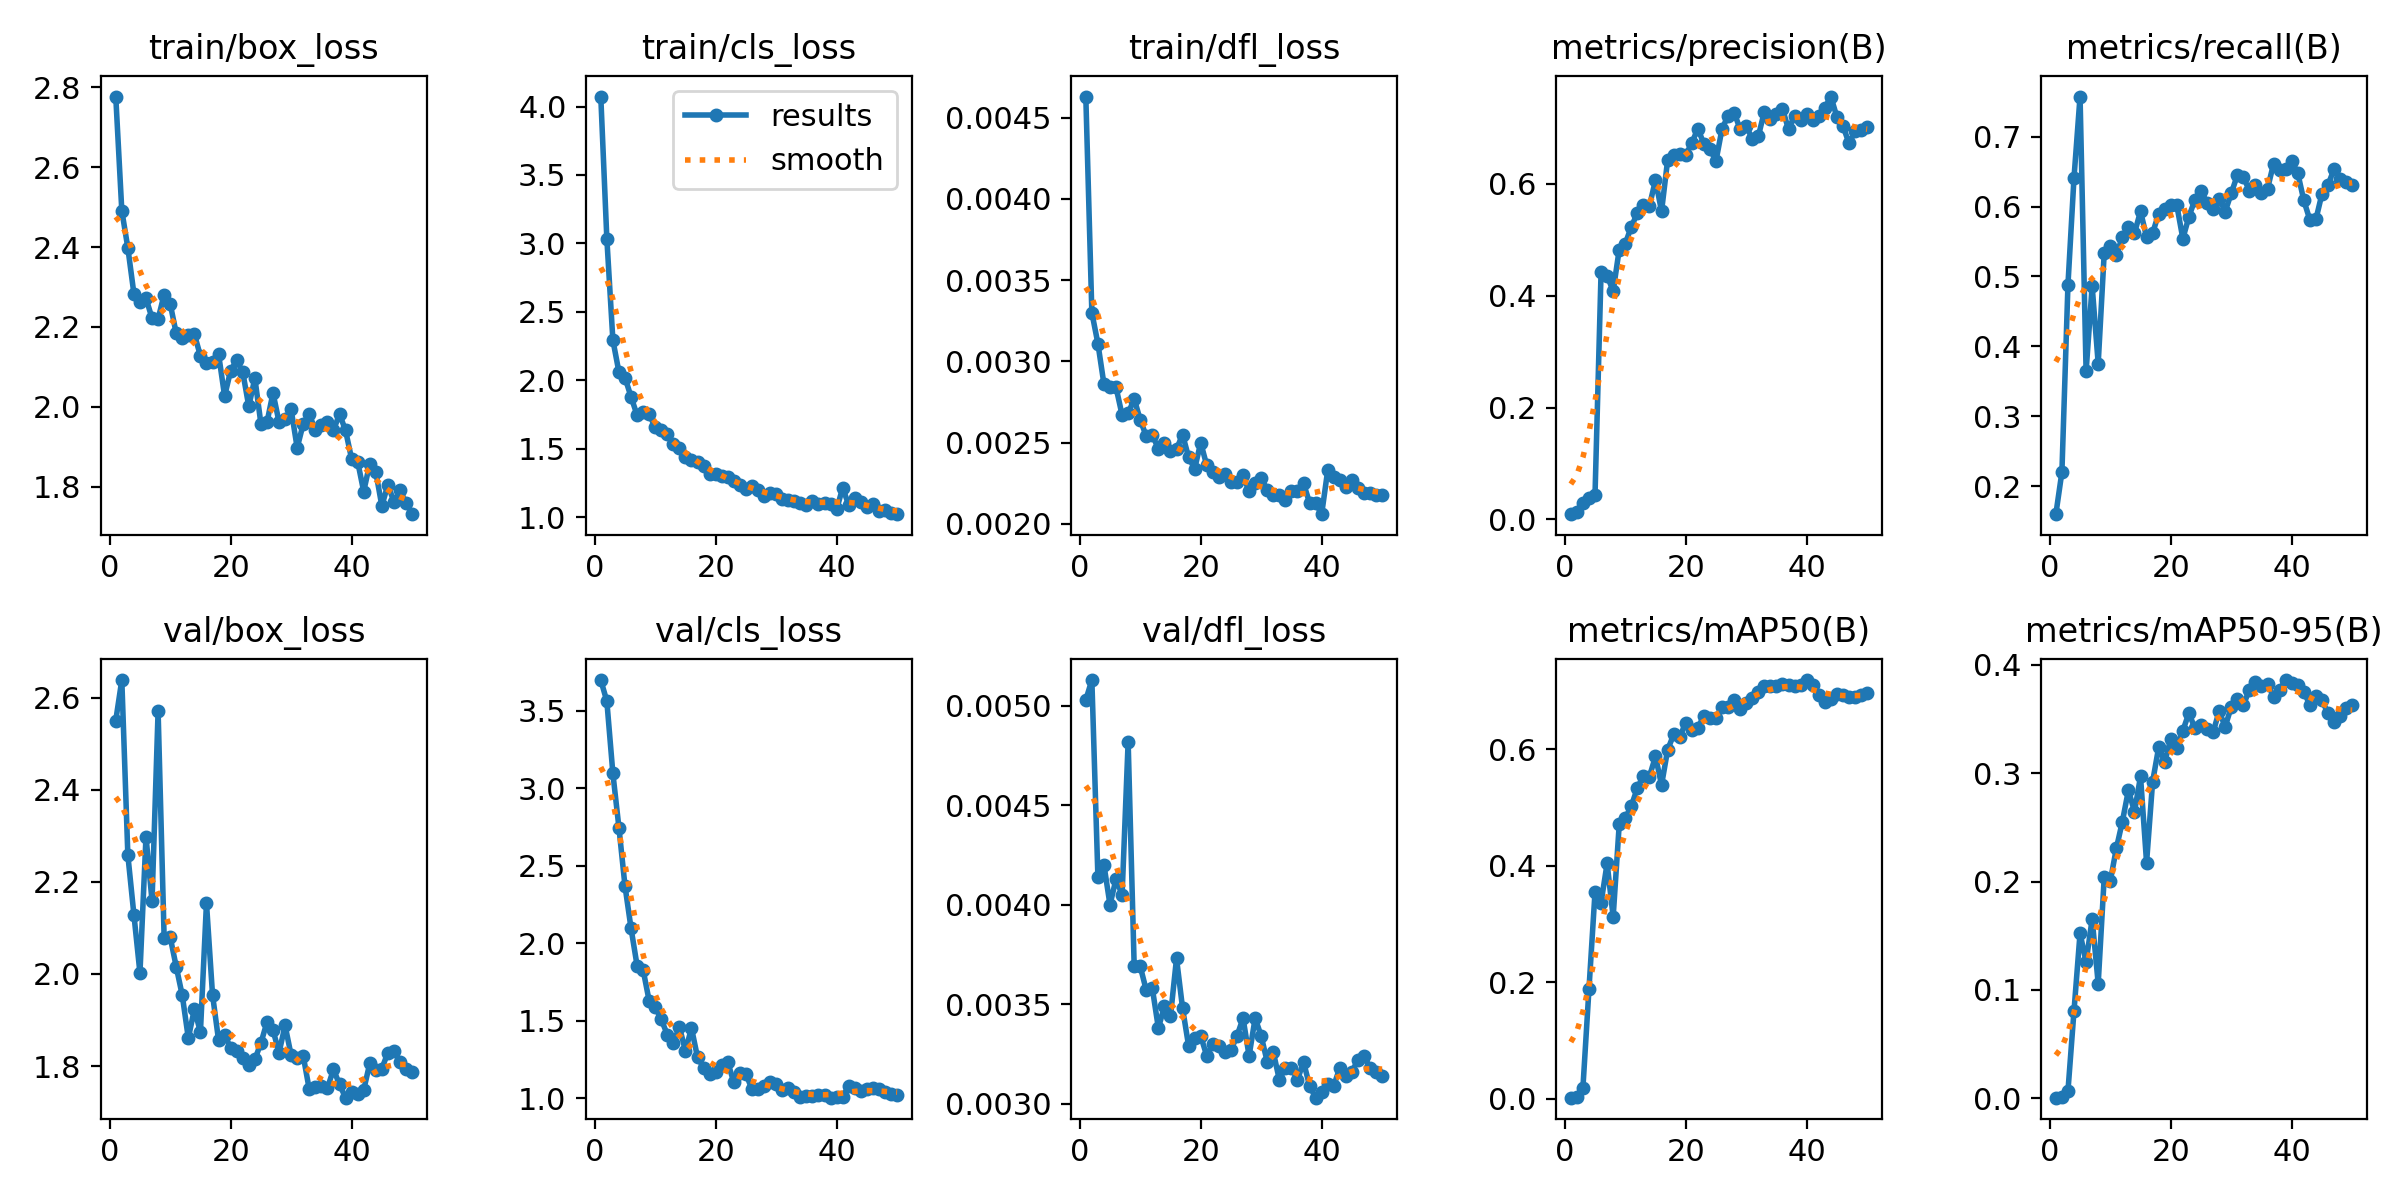

In [49]:
from IPython.display import Image, display

results_png = run_dir / "results.png"
if results_png.exists():
    display(Image(filename=str(results_png)))
else:
    print("No results.png yet.")

## Validation samples (labels vs predictions)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage
from ultralytics import YOLO

# Load trained model
weights_path = run_dir / "weights" / "best.pt"
if not weights_path.exists():
    weights_path = run_dir / "weights" / "last.pt"

# Resolve val images + labels dir from dataset yaml
with open(args["data"]) as f:
    data_cfg = yaml.safe_load(f)
val_dir = Path(data_cfg["path"]) / data_cfg["val"]
val_labels_dir = Path(str(val_dir).replace("/images/", "/labels/"))

IMG_EXT = {".jpg", ".jpeg", ".png"}
val_images = sorted(p for p in val_dir.iterdir() if p.suffix.lower() in IMG_EXT)

# How many images to show
N_SHOW = min(12, len(val_images))
sample = val_images[:N_SHOW]

model = YOLO(str(weights_path))
results = list(model.predict(source=[str(p) for p in sample], conf=0.25, iou=0.7, verbose=False))


def read_gt_boxes(lbl_path, img_w, img_h):
    """Read YOLO-format label file -> list of (x1, y1, x2, y2) in pixel coords."""
    boxes = []
    if not lbl_path.exists():
        return boxes
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        _, xc, yc, w, h = parts[:5]
        xc, yc, w, h = float(xc), float(yc), float(w), float(h)
        x1 = (xc - w / 2) * img_w
        y1 = (yc - h / 2) * img_h
        x2 = (xc + w / 2) * img_w
        y2 = (yc + h / 2) * img_h
        boxes.append((x1, y1, x2, y2))
    return boxes


ncols = 2
nrows = (len(sample) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14 * ncols, 10 * nrows))
axes = np.array(axes).reshape(-1)

for ax, img_path, res in zip(axes, sample, results):
    img = PILImage.open(img_path).convert("RGB")
    img_w, img_h = img.size
    ax.imshow(img)

    # Ground-truth boxes (drawn first, underneath)
    lbl_path = val_labels_dir / f"{img_path.stem}.txt"
    gt_boxes = read_gt_boxes(lbl_path, img_w, img_h)
    for x1, y1, x2, y2 in gt_boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor="red", facecolor="none", zorder=2,
        )
        ax.add_patch(rect)

    # Predicted boxes (drawn on top)
    pred_n = 0 if res.boxes is None else len(res.boxes)
    if pred_n > 0:
        xyxy = res.boxes.xyxy.cpu().numpy()
        for x1, y1, x2, y2 in xyxy:
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2.5, edgecolor="lime", facecolor="none", zorder=3,
            )
            ax.add_patch(rect)

    ax.set_title(
        f"{img_path.name}   GT={len(gt_boxes)} (red)  Pred={pred_n} (green)",
        fontsize=12,
    )
    ax.axis("off")

for ax in axes[len(sample):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Weights

In [ ]:
import matplotlib.image as mpimg
import numpy as np

plot_names = [
    "confusion_matrix.png", "confusion_matrix_normalized.png",
    "BoxPR_curve.png", "BoxF1_curve.png",
    "BoxP_curve.png", "BoxR_curve.png",
    "labels.jpg",
]
existing = [(n, run_dir / n) for n in plot_names if (run_dir / n).exists()]

if existing:
    ncols = 3
    nrows = (len(existing) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, (name, p) in zip(axes, existing):
        ax.imshow(mpimg.imread(p))
        ax.set_title(name, fontsize=9)
        ax.axis("off")
    for ax in axes[len(existing):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No diagnostic plots yet.")

## Count evaluation (MSE / MAE)

Runs the trained model on the validation set and compares predicted box count vs. ground-truth count per image.
This is the metric you care about if "how many people are in this frame" is the downstream question.

In [ ]:
for name in ["confusion_matrix.png", "confusion_matrix_normalized.png", "BoxPR_curve.png", "BoxF1_curve.png", "BoxP_curve.png", "BoxR_curve.png", "labels.jpg"]:
    p = run_dir / name
    if p.exists():
        print(name)
        display(Image(filename=str(p)))

In [ ]:
# 3. Load model and run inference on val set
from ultralytics import YOLO

model = YOLO(str(weights_path))

IMG_EXT = {".jpg", ".jpeg", ".png"}
val_images = sorted(p for p in val_images_dir.iterdir() if p.suffix.lower() in IMG_EXT)

pred_counts, gt_counts, names = [], [], []

results = model.predict(
    source=[str(p) for p in val_images],
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    verbose=False,
    stream=True,
)

for img_path, res in zip(val_images, results):
    # Predicted count
    pred_n = 0 if res.boxes is None else len(res.boxes)
    # Ground-truth count from label file
    lbl_path = val_labels_dir / f"{img_path.stem}.txt"
    gt_n = 0
    if lbl_path.exists():
        gt_n = sum(1 for line in lbl_path.read_text().splitlines() if line.strip())
    pred_counts.append(pred_n)
    gt_counts.append(gt_n)
    names.append(img_path.name)

pred_counts = np.array(pred_counts)
gt_counts = np.array(gt_counts)
errors = pred_counts - gt_counts

mae = np.mean(np.abs(errors))
mse = np.mean(errors ** 2)
rmse = np.sqrt(mse)
bias = np.mean(errors)

print(f"\n=== Count metrics on {len(val_images)} val images ===")
print(f"  MAE   (mean abs error)  = {mae:.3f}")
print(f"  MSE   (mean sq  error)  = {mse:.3f}")
print(f"  RMSE                    = {rmse:.3f}")
print(f"  Bias  (mean pred - gt)  = {bias:+.3f}   (positive = over-counts)")
print(f"  GT   range / mean       = [{gt_counts.min()}, {gt_counts.max()}] / {gt_counts.mean():.2f}")
print(f"  Pred range / mean       = [{pred_counts.min()}, {pred_counts.max()}] / {pred_counts.mean():.2f}")

In [ ]:
# 4. Plot predicted vs. ground-truth count + error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lo = 0
hi = max(pred_counts.max(), gt_counts.max()) + 1
axes[0].scatter(gt_counts, pred_counts, alpha=0.6)
axes[0].plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="y = x")
axes[0].set_xlabel("Ground-truth count")
axes[0].set_ylabel("Predicted count")
axes[0].set_title(f"Pred vs GT (MAE={mae:.2f}, RMSE={rmse:.2f})")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(errors, bins=range(int(errors.min()) - 1, int(errors.max()) + 2), edgecolor="k")
axes[1].axvline(0, color="k", linestyle="--", alpha=0.4)
axes[1].set_xlabel("Predicted − Ground-truth")
axes[1].set_ylabel("Number of images")
axes[1].set_title("Count error distribution")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Worst cases (largest abs error)
errs_df = pd.DataFrame({"image": names, "gt": gt_counts, "pred": pred_counts, "error": errors})
errs_df["abs_error"] = errs_df["error"].abs()
print("\nWorst 10 predictions by |error|:")
display(errs_df.sort_values("abs_error", ascending=False).head(10).reset_index(drop=True))